In [23]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf

In [24]:
import folium

In [25]:
import UBNA_localize_process_GCC__20250505 as localize

In [26]:
def plot_audio_seg_spectrogram(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
            labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

In [27]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),


In [28]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 2/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [29]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [30]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 19, 0, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_028/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_109/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_057/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_114/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_053/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_026/20260604_190000.WAV'),
 PosixPath

In [31]:
recording_start_dt_values = [dt.datetime(2026, 6, 4, 19, 4, 27, 800000)]

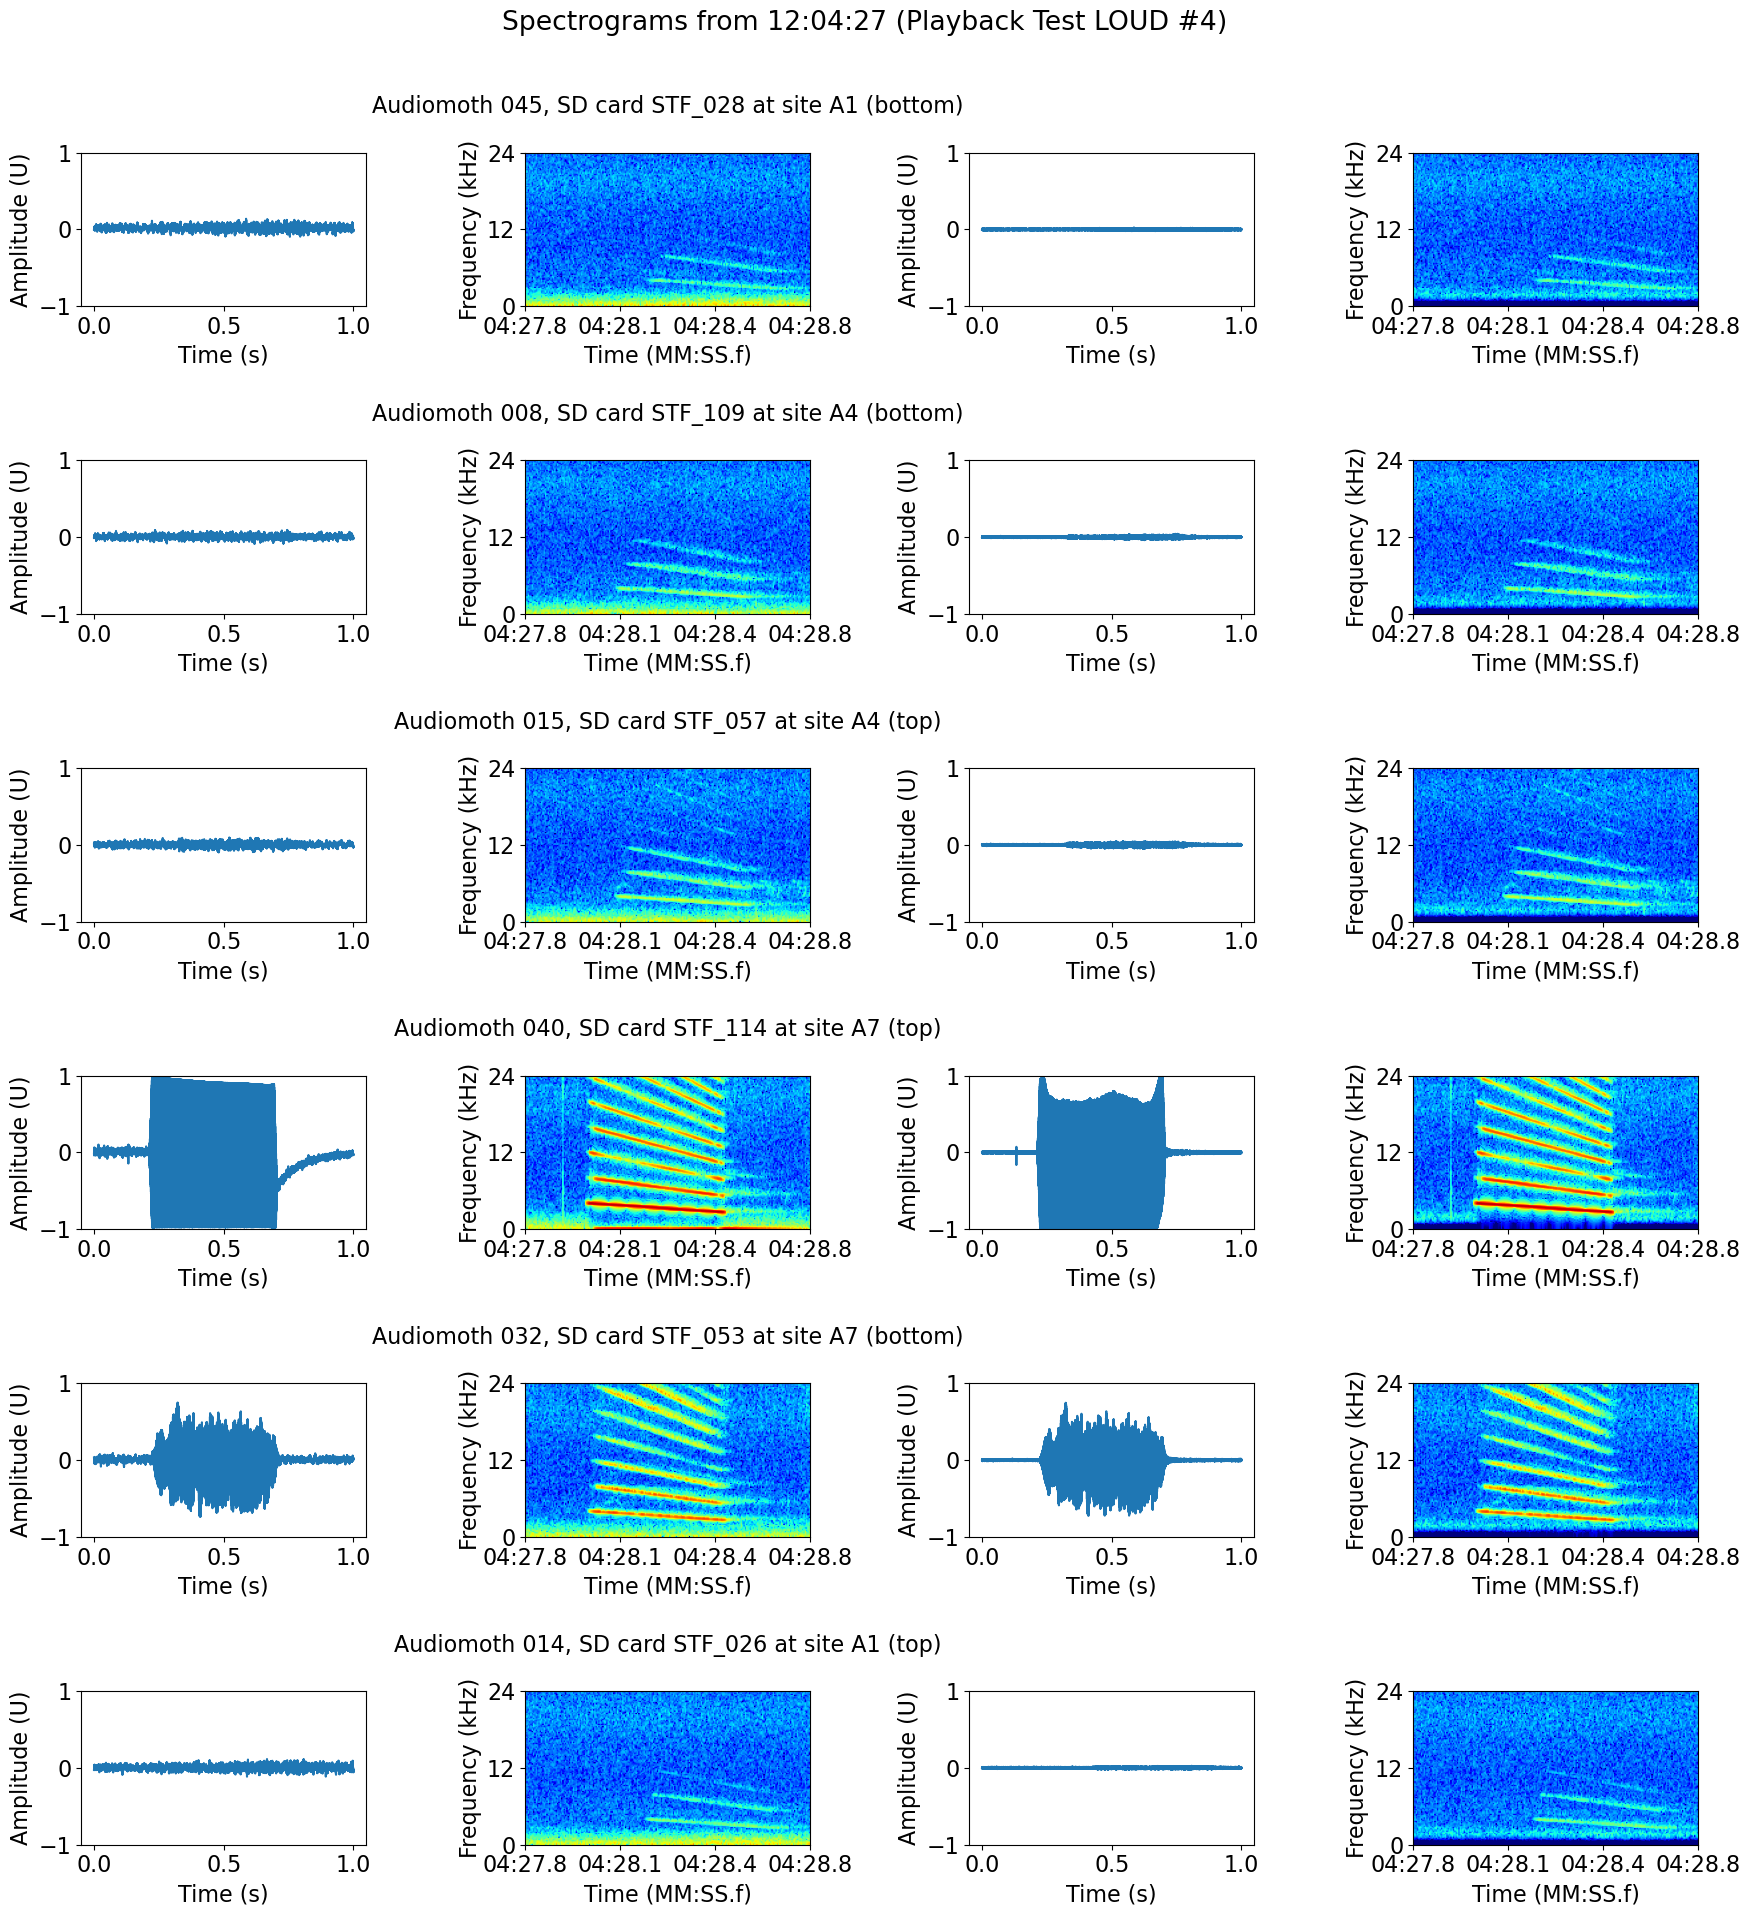

In [32]:
recording_start_dt = recording_start_dt_values[0]
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 4, figsize=(18, 3.2*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Playback Test LOUD #{int(3+1)})', y=1.0)

i = 0
highpassed_audio_segments = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg

        vmax = 0
        vmin = -100

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 3]
        spec, freqs, t, im = ax.specgram(highpassed_audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 2]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), highpassed_audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        ax = ax_all[i, 1]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", y=1.2, fontsize=16)
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 0]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        i+=1
fig.tight_layout()
plt.show()

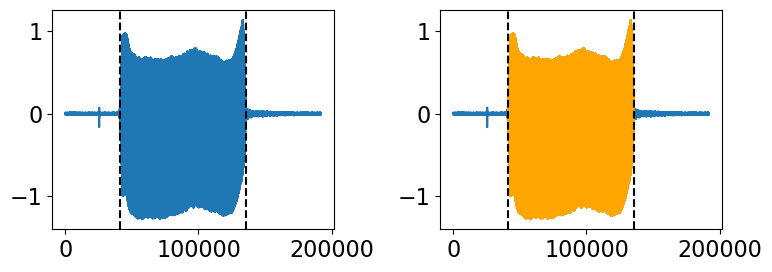

In [33]:
template_highpassed_signal = highpassed_audio_segments['040']
fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

first_over_threshold = np.where(template_highpassed_signal>=0.1)[0][0]
last_over_threshold = np.where(template_highpassed_signal>=0.1)[0][-1]
relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

ax = ax_all[0]
ax.plot(template_highpassed_signal)
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

ax = ax_all[1]
ax.plot(template_highpassed_signal)
ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

fig.tight_layout()
plt.show()

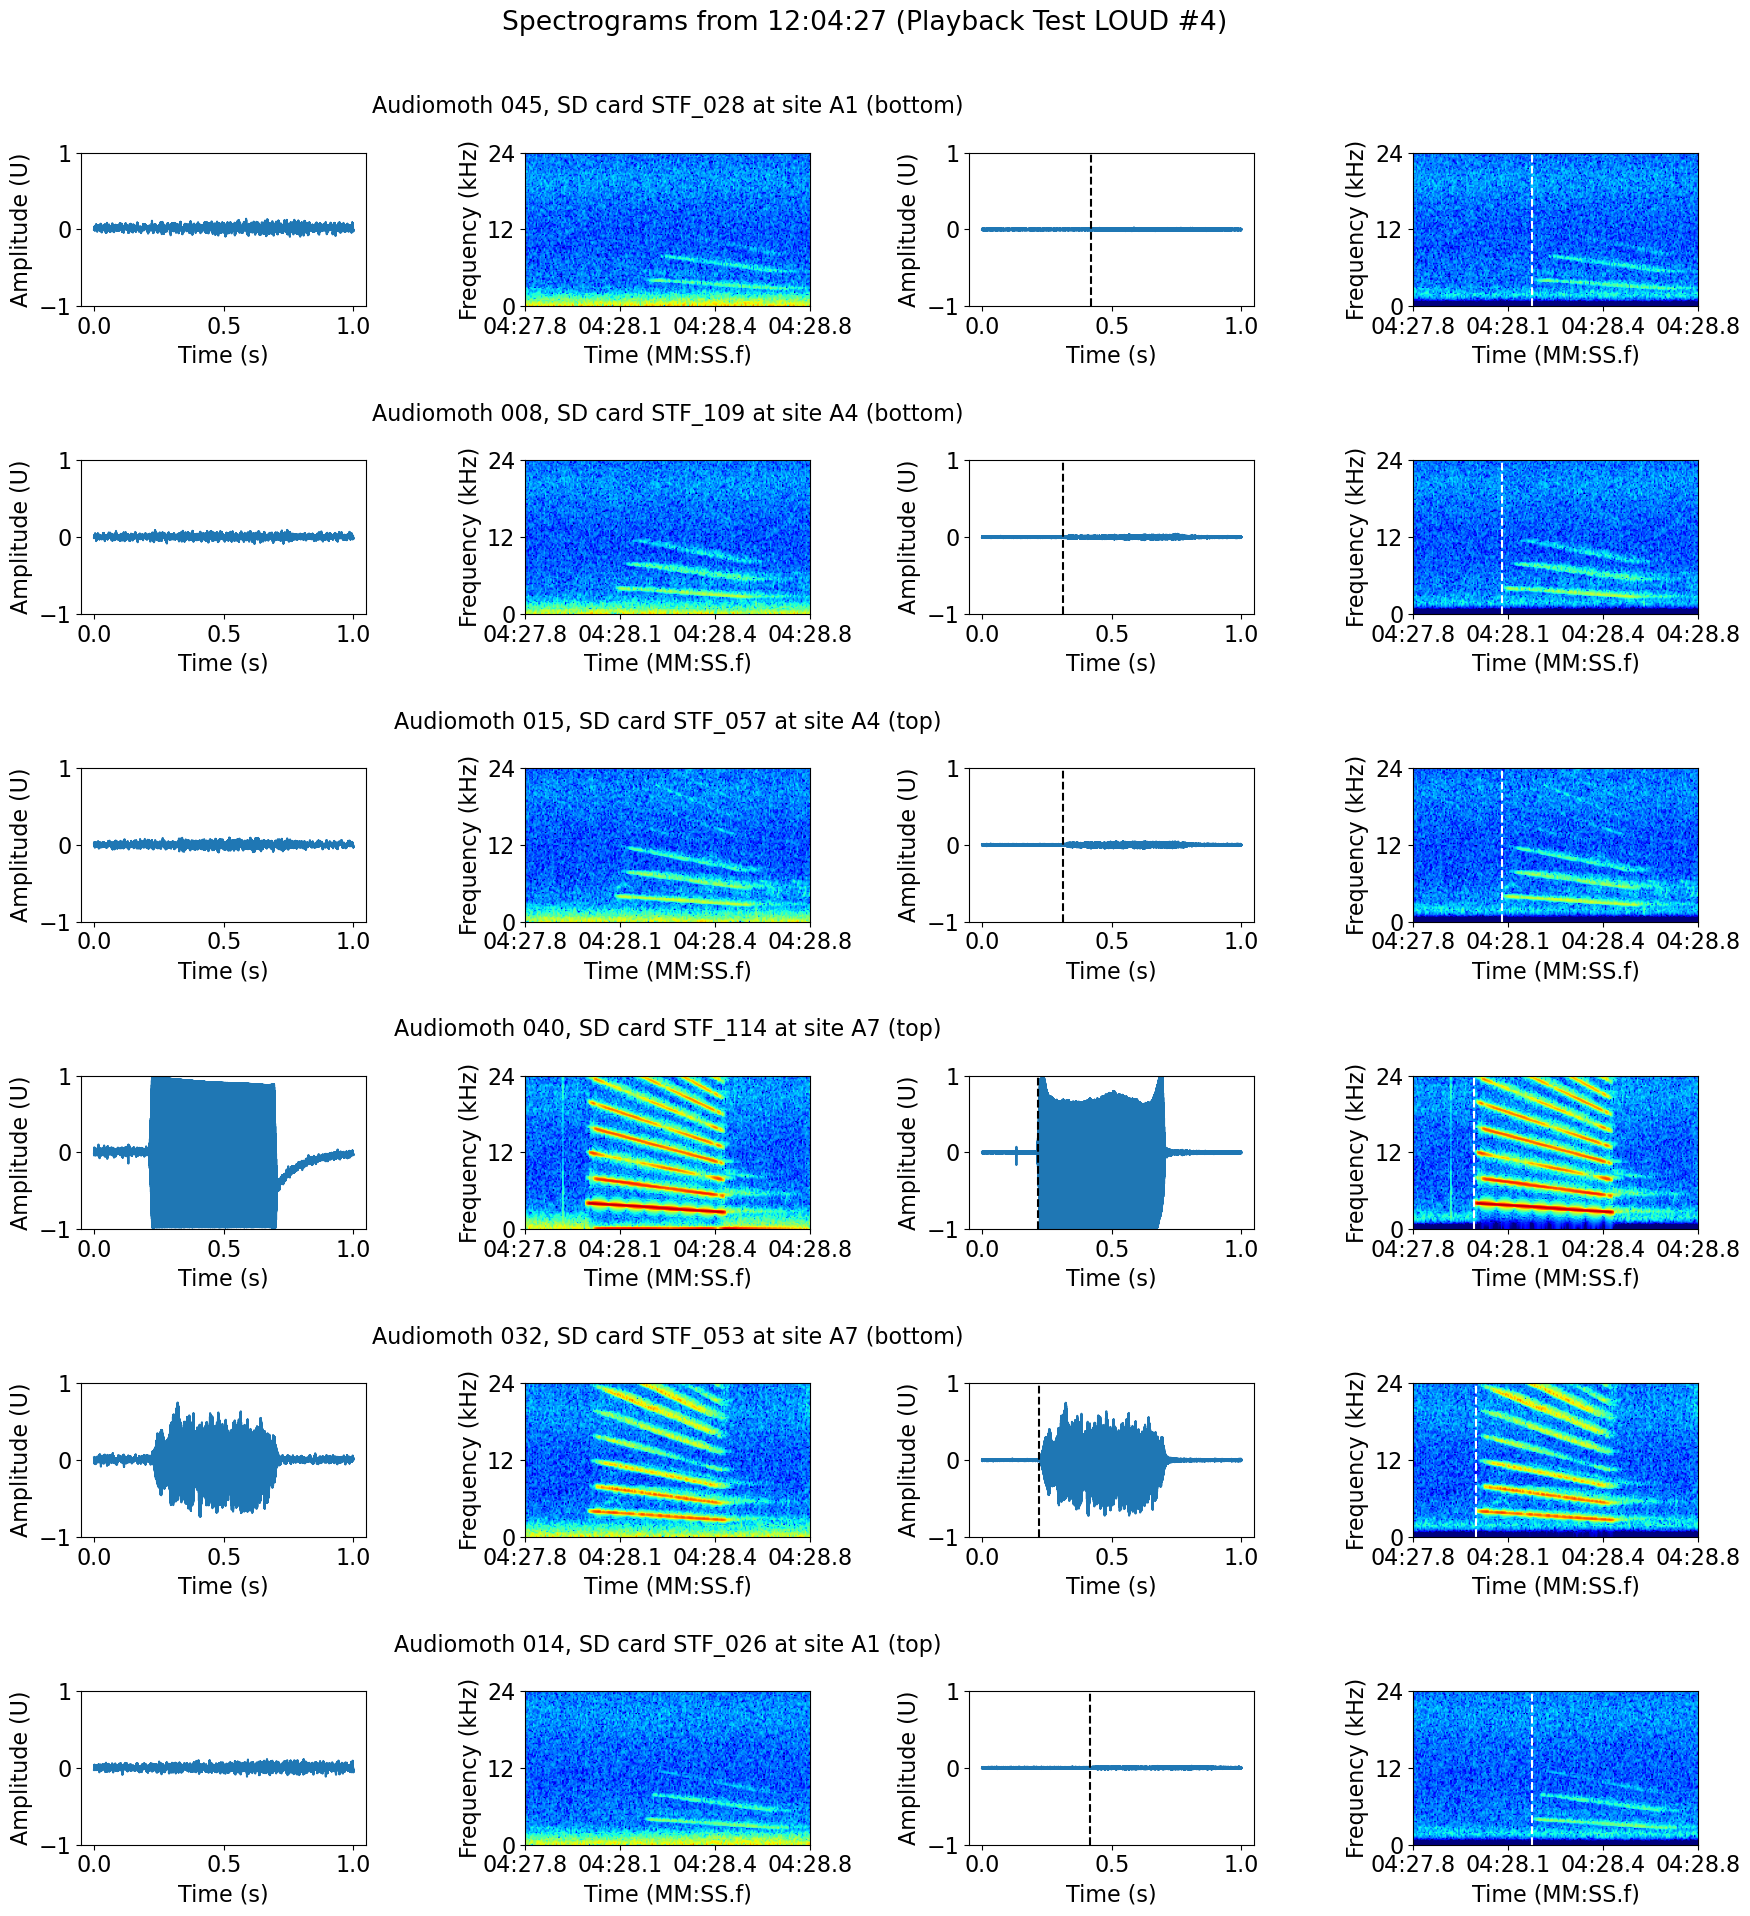

In [34]:
recording_start_dt = recording_start_dt_values[0]
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 4, figsize=(18, 3.2*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Playback Test LOUD #{int(3+1)})', y=1.0)

i = 0
time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_dictionary = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)

        signal1 = highpassed_audio_seg
        signal2 = relevant_template_highpassed_signal
        cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
        lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / SAMPLERATE
        time_delay_in_seconds_matrix[i] = time_delay_in_seconds
        time_delay_in_seconds_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds

        vmax = 0
        vmin = -100

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 3]
        spec, freqs, t, im = ax.specgram(highpassed_audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        ax.axvline(x=time_delay_in_seconds*(fs/2), linestyle='dashed', color='w')
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 2]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), highpassed_audio_seg)
        ax.axvline(x=time_delay_in_seconds, linestyle='dashed', color='k')
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        ax = ax_all[i, 1]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", y=1.2, fontsize=16)
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 0]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        i+=1
fig.tight_layout()
plt.show()

In [35]:
(time_delay_in_seconds_matrix - time_delay_in_seconds_dictionary['040']) * 343

array([69.95949479, 33.61578646, 33.26028125,  0.        ,  2.19913021,
       69.11271354])

In [36]:
valid_csv_files = []
for csv_file in all_csv_files:
    csv_file_dt = dt.datetime.strptime(csv_file.name, '%Y%m%d_%H%M%S.CSV')
    if csv_file_dt == dt.datetime(2026, 6, 4, 19, 0, 0):
        valid_csv_files += [csv_file]
valid_csv_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_028/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_109/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_057/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_114/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_053/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_190000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_026/20260604_190000.CSV'),
 PosixPath

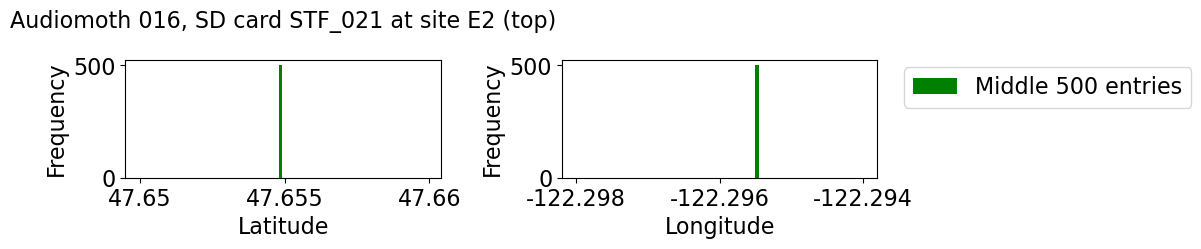

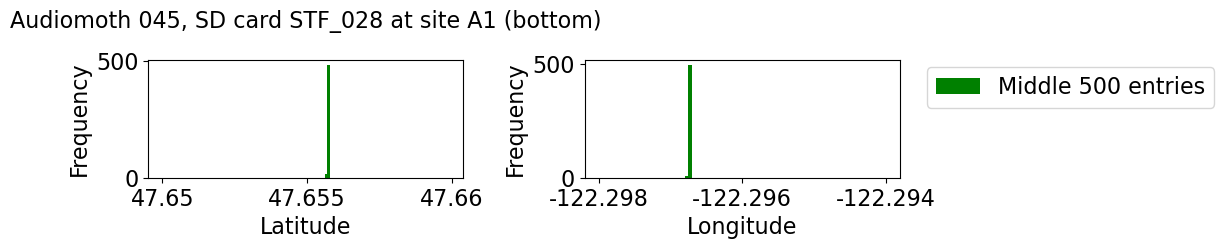

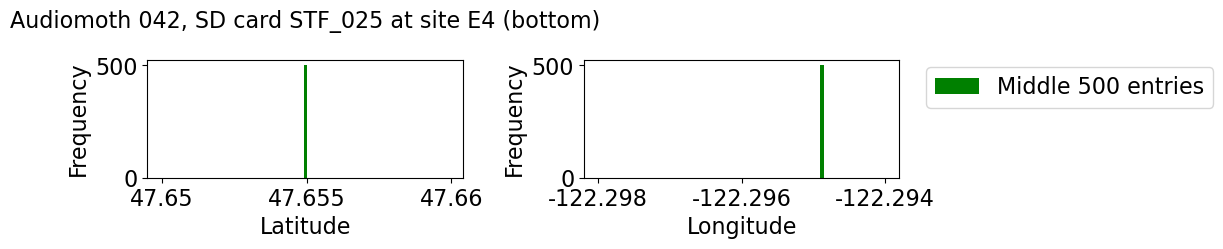

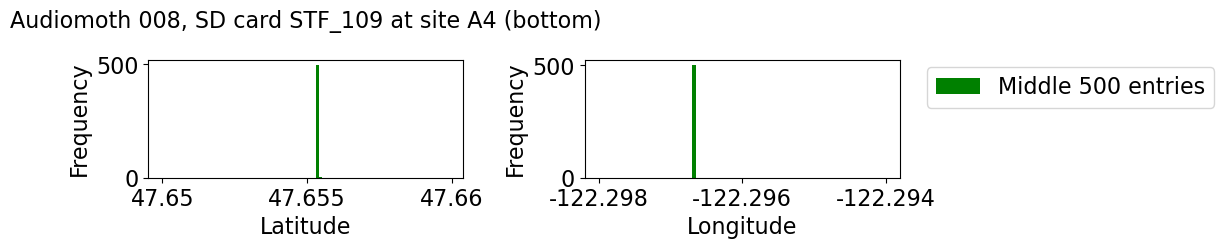

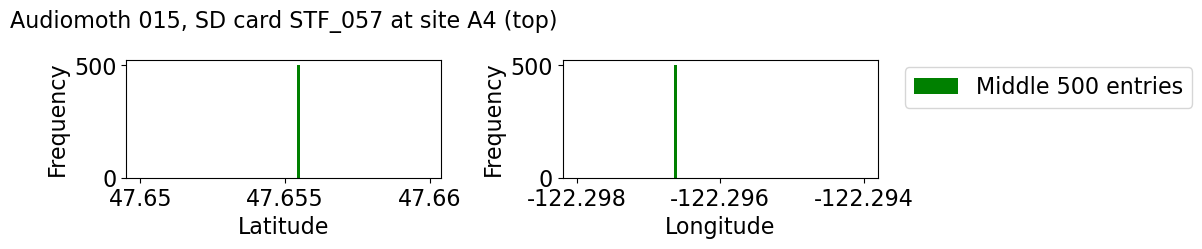

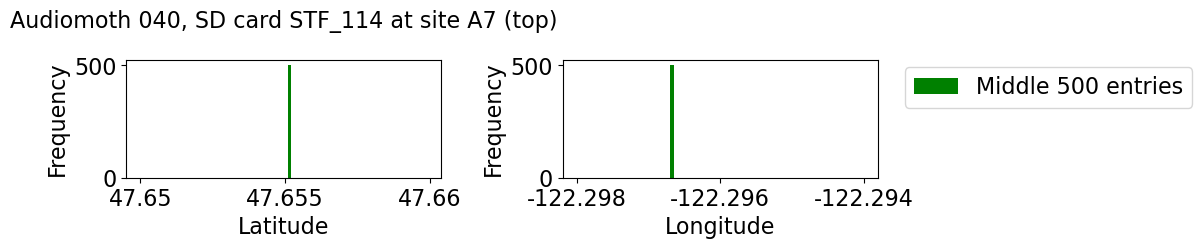

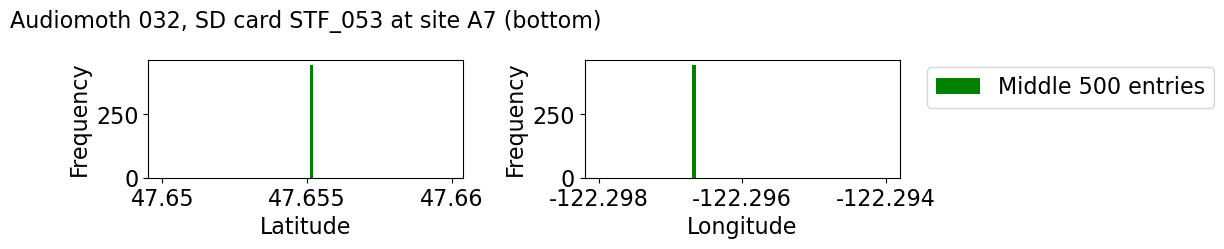

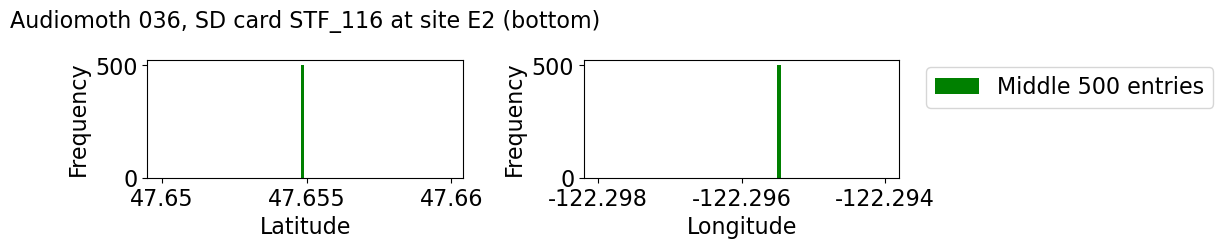

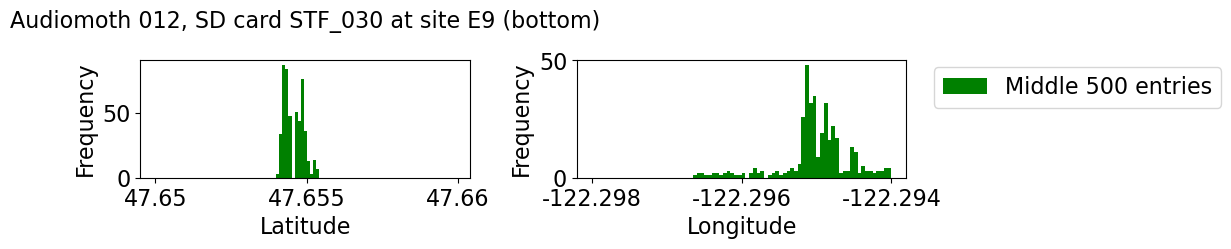

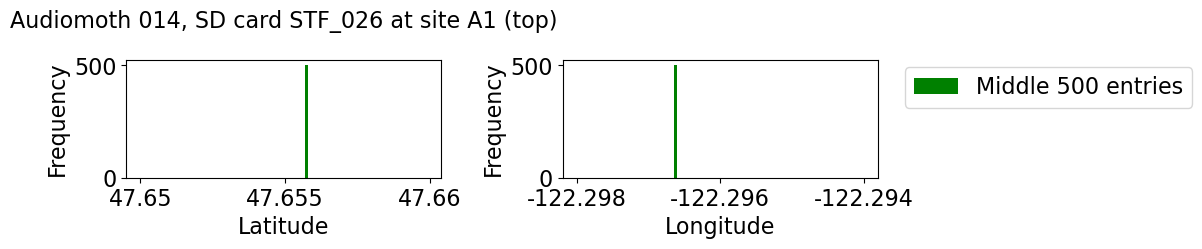

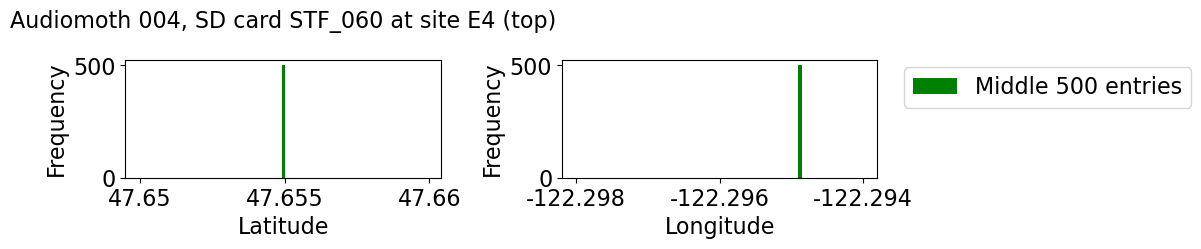

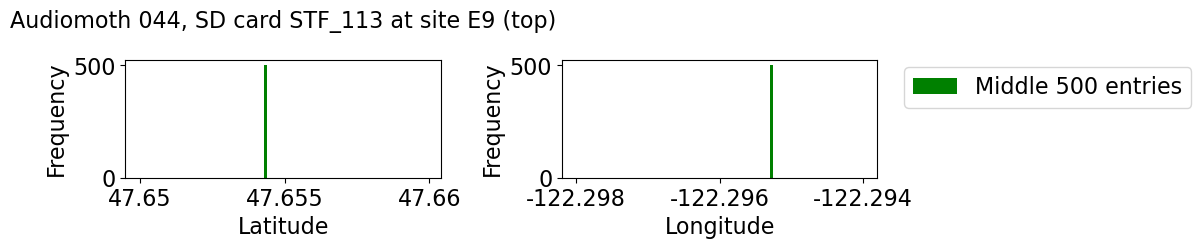

In [37]:
for example_csv_file in valid_csv_files:
    wav_SD_card = example_csv_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    audiomoth_GPS_csv = pd.read_csv(example_csv_file, index_col=0)

    lat = audiomoth_GPS_csv["LAT_DEG"] + audiomoth_GPS_csv["LAT_MIN"] / 60
    lon = audiomoth_GPS_csv["LONG_DEG"] + audiomoth_GPS_csv["LONG_MIN"] / 60

    lat = lat.where(audiomoth_GPS_csv["LAT_DIR"].str.upper() != "S", -lat)
    lon = lon.where(audiomoth_GPS_csv["LONG_DIR"].str.upper() != "W", -lon)

    fig, ax_all = plt.subplots(1, 2, figsize=(12, 3))
    ax = ax_all[0]
    ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", y=1.2, fontsize=16)
    # ax.hist(lat[:500], bins=np.arange(47.65, 47.66, 0.0001), color='blue', label='First 500 entries')
    ax.hist(lat[500:1000], bins=np.arange(47.65, 47.66, 0.0001), color='green', label='Middle 500 entries')
    # ax.hist(lat[1000:], bins=np.arange(47.65, 47.66, 0.0001), color='orange', label='After 1000 entries')
    ax.set_xticks(np.linspace(47.65, 47.66, 3), np.linspace(47.65, 47.66, 3).round(3))
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Latitude')

    ax = ax_all[1]
    # ax.hist(lon[:500], bins=np.arange(-122.298, -122.294, 0.00005), color='blue', label='First 500 entries')
    ax.hist(lon[500:1000], bins=np.arange(-122.298, -122.294, 0.00005), color='green', label='Middle 500 entries')
    # ax.hist(lon[1000:], bins=np.arange(-122.298, -122.294, 0.00005), color='orange', label='After 1000 entries')
    ax.set_xticks(np.linspace(-122.298, -122.294, 3), np.linspace(-122.298, -122.294, 3).round(3))
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Longitude')
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.03))

    fig.tight_layout()
    plt.show()

In [42]:
audiomoth_to_color = {'014':'green', '045':'green',
                       '015':'red', '008':'red',
                       '040':'cyan', '032':'cyan',
                       '016':'blue', '036':'blue',
                       '004':'orange', '042':'orange',
                       '020':'brown',
                       '044':'pink', '012':'pink'}

In [43]:
map = folium.Map(location=[47.65482429333334, -122.29547748000003], zoom_start=18, tiles="OpenStreetMap",)

for example_csv_file in valid_csv_files:
    wav_SD_card = example_csv_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    audiomoth_GPS_csv = pd.read_csv(example_csv_file, index_col=0)

    lat = audiomoth_GPS_csv["LAT_DEG"] + audiomoth_GPS_csv["LAT_MIN"] / 60
    lon = audiomoth_GPS_csv["LONG_DEG"] + audiomoth_GPS_csv["LONG_MIN"] / 60

    lat = lat.where(audiomoth_GPS_csv["LAT_DIR"].str.upper() != "S", -lat)
    lon = lon.where(audiomoth_GPS_csv["LONG_DIR"].str.upper() != "W", -lon)

    # lat and lon are your pandas Series
    points = pd.DataFrame({"lat": lat[500:1000], "lon": lon[500:1000]}).dropna()
    for _, row in points.iterrows():
        folium.CircleMarker(location=[row["lat"], row["lon"]], radius=2, color=audiomoth_to_color[wav_AUDIOMOTH], fill=True, fill_opacity=0.7).add_to(map)

map